Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

=== Classification Results ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

=== Regression Results ===
Mean Squared Error: 2900.193628493482


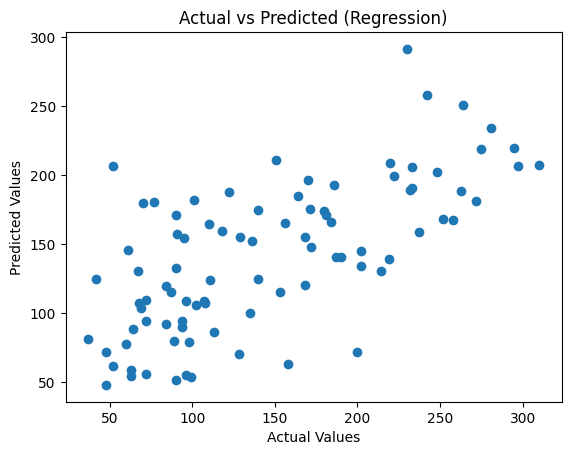

ValueError: X has 10 features, but LogisticRegression is expecting 4 features as input.

In [2]:
# =========================================
# STEP 1: Install & Import Libraries
# =========================================
!pip install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

from sklearn.datasets import load_iris, load_diabetes

# =========================================
# PART 1: CLASSIFICATION (Iris Dataset)
# =========================================

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Feature Names:", iris.feature_names)
print("Classes:", iris.target_names)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("\n=== Classification Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# PART 2: REGRESSION (Diabetes Dataset)
# =========================================

# Load dataset
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)

print("\n=== Regression Results ===")
print("Mean Squared Error:", mse)

# =========================================
# PART 3: Visualization (Regression)
# =========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Regression)")
plt.show()

# =========================================
# PART 4: Predict New Data
# =========================================

# Classification example
sample = X_test[0].reshape(1, -1)
prediction = clf.predict(sample)

print("\nPrediction for sample (classification):", prediction)

# Regression example
sample_reg = X_test[0].reshape(1, -1)
prediction_reg = reg.predict(sample_reg)

print("Prediction for sample (regression):", prediction_reg)